## Exercise 1: Polynomial Regression

Generate a regression dataset:

- **X generation:** `X = (2 - 3*np.random.normal(0,1,200)).reshape(200,1)`
- **y generation:** `y = 0.5*X^3 - 2*X^2 + X + np.random.normal(-3,3,200).reshape(-1,1)`

Apply a polynomial regression algorithm and plot the predictions of the model for a test set `X_test = np.linspace(-5, 10, 200).reshape(200, 1)`.


In [13]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [14]:
# dataset
X = (2 - 3 * np.random.normal(0, 1, 200)).reshape(200, 1)
y = 0.5 * X ** 3 - 2 * X ** 2 + X + np.random.normal(-3, 3, 200).reshape(-1, 1)

In [15]:
# the degree should be 3 because y is a cubic function
poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)
# X_poly now contains the original feature of X plus the square of this feature

In [16]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([-3.57938198]), array([[ 0.91600264, -1.95831187,  0.49732923]]))

In [17]:
# generate test data for prediction
X_test = np.linspace(-5, 10, 200).reshape(200, 1)
X_test_poly = poly_features.transform(X_test)
y_test = lin_reg.predict(X_test_poly)

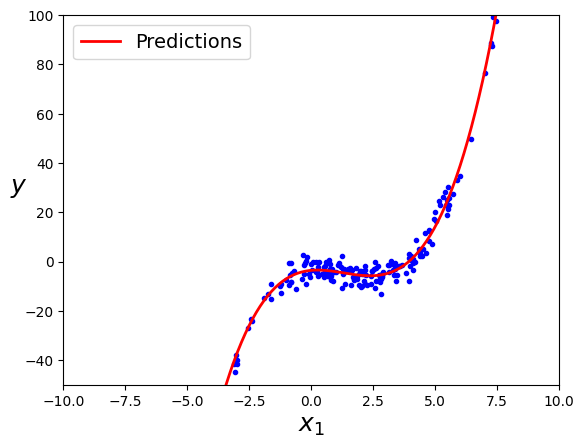

In [18]:
plt.plot(X, y, "b.")
plt.plot(X_test, y_test, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-10, 10, -50, 100])
plt.show()

## Exercise 2: Ridge Regression with Mini-Batch Gradient Descent
Generate a regression dataset:
- **X generation:** `X = 3*np.random.rand(150,1)`
- **y generation:** `y = -2 + 3*X + np.random.randn(150, 1)`

Perform ridge regression using mini-batch gradient descent with the following parameters:
- Learning rate: 0.06
- Epochs: 15
- Batch size: 10
- Lambda (λ): 0.01

Plot the prediction of the model and print the model weights.


In [19]:
# date
eta = 0.06
n_epochs = 15
batch_size = 10
n = 150 # luam din generarea lui x si y
alpha = 0.01

In [20]:
# dataset
X = 3 * np.random.rand(150, 1)
y = -2 + 3 * X + np.random.randn(150, 1)

print(X.shape)
print(y.shape)

(150, 1)
(150, 1)


In [21]:
w = np.random.randn(2,1)  # random initialization
print(w.shape)

X_1 = np.c_[np.ones((n, 1)), X]

(2, 1)


In [22]:
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(n)
    X_1_shuffled = X_1[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range(0, n, batch_size):
        xi = X_1_shuffled[i:i+batch_size]
        yi = y_shuffled[i:i+batch_size]
        gradients = 1/batch_size * xi.T.dot(xi.dot(w) - yi)
        w = w - eta * gradients

print("The final model weights : \n", w)

The final model weights : 
 [[-1.90984654]
 [ 3.01928158]]


In [23]:
X_test = np.linspace(0, 3, n).reshape(n, 1)  # generam 150 de puncte intre 0 si 3 pt test
X_test_1 = np.c_[np.ones((n, 1)), X_test]
y_test = X_test_1.dot(w)

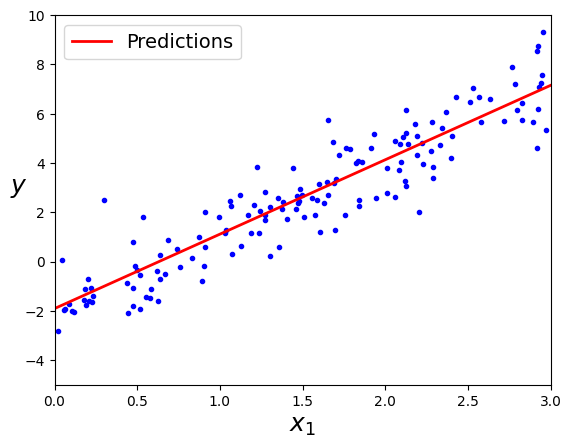

In [24]:
plt.plot(X, y, "b.")
plt.plot(X_test, y_test, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 3, -5, 10])
plt.show()

## Exercise 3: Softmax Regression on Digits Dataset
Apply the softmax regression algorithm using the `digits` dataset.

- **Dataset loading:** Call the `load_digits` function.
- **Data splitting:** Split the data such that the test set comprises 35% of the initial dataset.
- **Initial output:** Print the shapes of the training and testing datasets.
- **Algorithm training:** Train the algorithm for 700 epochs, using the "lbfgs" solver, and set the hyperparameter `C` to 5.
- **Post-training output:** After the model is trained, print the test set accuracy. Additionally, predict and print the probabilities that the model assigned to the ten classes for the second example in the test set.


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [26]:
digits_datasets = datasets.load_digits()

TEST_SIZE = 0.35

X_train, X_test, y_train, y_test = train_test_split(digits_datasets['data'], digits_datasets['target'], test_size = TEST_SIZE,random_state=0)

In [27]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1168, 64), (1168,), (629, 64), (629,))

In [28]:
NUM_EPOCHS = 700

softmax_reg = LogisticRegression(max_iter=NUM_EPOCHS, multi_class="multinomial", solver="lbfgs", C=5, random_state=42)
softmax_reg.fit(X_train, y_train)
softmax_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


0.9523052464228935

In [29]:
softmax_reg.predict([X_test[1]])

array([8])

In [30]:
# the second example
softmax_reg.predict_proba([X_test[1]])

array([[1.89727696e-10, 1.80624818e-07, 3.84545988e-07, 3.03205093e-15,
        8.40303382e-04, 1.97522437e-07, 1.05766564e-09, 1.40771079e-12,
        9.99158932e-01, 6.31705903e-10]])

In [31]:
# find more about the dataset

print(digits_datasets.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [32]:
X_test[1].shape, y_test[1]

((64,), np.int64(8))

<function matplotlib.pyplot.show(close=None, block=None)>

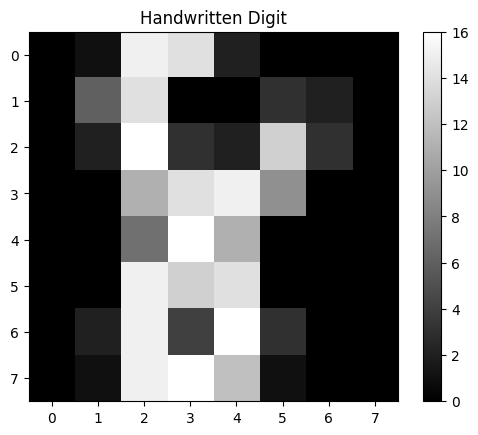

In [33]:
digit_array = X_test[1]

digit_image = digit_array.reshape(8, 8)

plt.imshow(digit_image, cmap = 'gray', interpolation = 'nearest')
plt.colorbar()
plt.title('Handwritten Digit')
plt.show